# HEM classique sur FineTune3 depuis Drive
Ce notebook charge le dataset clean depuis Google Drive, charge FineTune3 depuis Google Drive, applique un Hard Example Mining classique (sans attaques adversariales), et sauvegarde le meilleur modèle à chaque époque dans Drive.

In [ ]:
# CELL 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip uninstall -y sympy torch torchvision
!pip install sympy==1.13.3 torch torchvision --no-cache-dir

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Found existing installation: torchvision 0.25.0+cpu
Uninstalling torchvision-0.25.0+cpu:
  Successfully uninstalled torchvision-0.25.0+cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 218.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 251.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 192.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 237.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 202.9 MB/s 

In [ ]:
# CELL 2 — Imports
import os, json, random, gc
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, roc_auc_score
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

DEVICE = cuda


In [ ]:
# CELL 3 — Paths & Global Configuration
from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive')

# Dataset clean already prepared in Drive
DATA_ROOT = DRIVE_ROOT / 'outputs_swin_lccfasd_robust2' / 'clean_dataset'

# FineTune3 base model in Drive
BASE_MODEL_PATH = DRIVE_ROOT / 'outputs_swin_lccfasd_robust2' / '3_finetune' / 'best_3_finetune.pth'

# Output directory for HEM
OUT_ROOT = DRIVE_ROOT / 'outputs_swin_lccfasd_HEM_classic'
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SPLITS = {
    'train': DATA_ROOT / 'train',
    'val':   DATA_ROOT / 'val',
    'test':  DATA_ROOT / 'test',
}

MODEL_NAME  = 'swin_base_patch4_window7_224'
NUM_CLASSES = 2
IMG_SIZE    = 224
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]

CFG = {
    'batch_size': 16,
    'num_workers': 2,
    'num_epochs': 8,
    'lr_backbone': 2e-6,
    'lr_classifier': 8e-6,
    'weight_decay': 1e-4,
    'grad_clip': 1.0,
    'label_smoothing': 0.05,
    'early_stop_patience': 3,

    # HEM classic
    'hard_ratio': 0.5,      # keep top 50% hardest examples in each batch
    'gamma_hard': 1.5,      # weight boost for hard examples
}

print('=' * 70)
print('CONFIG')
print('=' * 70)
print('DATA_ROOT       :', DATA_ROOT)
for k, v in SPLITS.items():
    print(f'{k:<12}: {v} | exists={v.exists()}')
print('BASE_MODEL_PATH :', BASE_MODEL_PATH, '| exists =', BASE_MODEL_PATH.exists())
print('OUT_ROOT        :', OUT_ROOT)
print('-' * 70)
for k, v in CFG.items():
    print(f'{k:<20}: {v}')

CONFIG
DATA_ROOT       : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/clean_dataset
train       : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/clean_dataset/train | exists=True
val         : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/clean_dataset/val | exists=True
test        : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/clean_dataset/test | exists=True
BASE_MODEL_PATH : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/3_finetune/best_3_finetune.pth | exists = True
OUT_ROOT        : /content/drive/MyDrive/outputs_swin_lccfasd_HEM_classic
----------------------------------------------------------------------
batch_size          : 16
num_workers         : 2
num_epochs          : 8
lr_backbone         : 2e-06
lr_classifier       : 8e-06
weight_decay        : 0.0001
grad_clip           : 1.0
label_smoothing     : 0.05
early_stop_patience : 3
hard_ratio          : 0.5
gamma_hard          : 1.5


In [ ]:
# CELL 4 — Dataset from Drive (clean, no augmentation)
eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

REAL_NAMES  = {'real'}
SPOOF_NAMES = {'spoof', 'fake', 'attack'}
IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

class LCCFASDDataset(Dataset):
    """Label convention: 0 = real, 1 = spoof"""
    def __init__(self, split_dir, transform=None):
        self.transform = transform
        self.samples = []
        self.labels  = []

        split_dir = Path(split_dir)
        for cls_dir in sorted(split_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            name = cls_dir.name.lower()
            if name in REAL_NAMES:
                label = 0
            elif name in SPOOF_NAMES:
                label = 1
            else:
                continue

            for f in cls_dir.rglob('*'):
                if f.is_file() and f.suffix.lower() in IMG_EXTS:
                    self.samples.append((f, label))
                    self.labels.append(label)

        if not self.samples:
            raise RuntimeError(f'No images found in {split_dir}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, label

train_ds = LCCFASDDataset(SPLITS['train'], transform=eval_tf)
val_ds   = LCCFASDDataset(SPLITS['val'],   transform=eval_tf)
test_ds  = LCCFASDDataset(SPLITS['test'],  transform=eval_tf)

train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'], shuffle=True,
    num_workers=CFG['num_workers'], pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=CFG['batch_size'], shuffle=False,
    num_workers=CFG['num_workers'], pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=CFG['batch_size'], shuffle=False,
    num_workers=CFG['num_workers'], pin_memory=True
)

counts = Counter(train_ds.labels)
n_real  = counts.get(0, 0)
n_spoof = counts.get(1, 0)

w_raw = torch.tensor([1.0 / max(n_real, 1), 1.0 / max(n_spoof, 1)], dtype=torch.float32)
CLASS_WEIGHTS = (w_raw / w_raw.sum() * 2).to(DEVICE)

print('Train class counts:', counts)
print('Class weights     :', CLASS_WEIGHTS.tolist())
print('Batches           : train =', len(train_loader), '| val =', len(val_loader), '| test =', len(test_loader))

Train class counts: Counter({1: 7035, 0: 1173})
Class weights     : [1.7141813039779663, 0.2858186960220337]
Batches           : train = 513 | val = 73 | test = 474


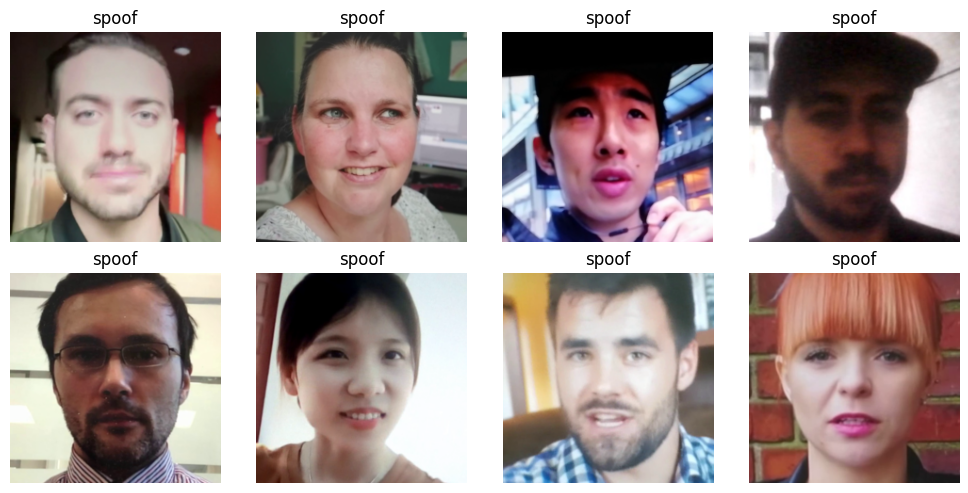

In [ ]:
# CELL 5 — Quick sample visualization
def denorm(x):
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    return torch.clamp(x.cpu() * std + mean, 0, 1)

idxs = np.random.choice(len(train_ds), size=min(8, len(train_ds)), replace=False)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, idx in zip(axes.flatten(), idxs):
    img, y = train_ds[idx]
    ax.imshow(denorm(img).permute(1,2,0))
    ax.set_title('real' if y == 0 else 'spoof')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# CELL 6 — Model helpers
def build_model():
    model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
    return model.to(DEVICE)

def load_base_model():
    assert BASE_MODEL_PATH.exists(), f'Not found: {BASE_MODEL_PATH}'
    model = build_model()
    state = torch.load(BASE_MODEL_PATH, map_location=DEVICE)
    if isinstance(state, dict) and 'model' in state:
        state = state['model']
    model.load_state_dict(state, strict=False)
    return model

def build_optimizer(model):
    backbone, classifier = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if 'head' in name or 'classifier' in name:
            classifier.append(p)
        else:
            backbone.append(p)
    return torch.optim.AdamW(
        [
            {'params': backbone, 'lr': CFG['lr_backbone']},
            {'params': classifier, 'lr': CFG['lr_classifier']},
        ],
        weight_decay=CFG['weight_decay']
    )

criterion_eval = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=CFG['label_smoothing'])
print('Model helpers ready.')

Model helpers ready.


In [ ]:
# CELL 7 — Metrics and save helpers
def compute_metrics(y_true, y_pred, y_prob, loss):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    far = (fp / max(tn + fp, 1)) * 100.0
    frr = (fn / max(fn + tp, 1)) * 100.0
    hter = (far + frr) / 2.0

    try:
        auc = roc_auc_score(y_true, y_prob[:, 1]) * 100.0
    except Exception:
        auc = float('nan')

    return {
        'acc': accuracy_score(y_true, y_pred) * 100.0,
        'prec_macro': precision_score(y_true, y_pred, average='macro', zero_division=0) * 100.0,
        'rec_macro': recall_score(y_true, y_pred, average='macro', zero_division=0) * 100.0,
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0) * 100.0,
        'bacc': balanced_accuracy_score(y_true, y_pred) * 100.0,
        'hter': hter,
        'far': far,
        'frr': frr,
        'auc': auc,
        'loss': loss,
        'cm': cm.tolist(),
    }

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    for x, y in tqdm(loader, desc='eval', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        probs = torch.softmax(logits, dim=1)

        running_loss += loss.item() * x.size(0)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(logits.argmax(1).cpu().numpy().tolist())
        y_prob.append(probs.cpu().numpy())

    y_prob = np.concatenate(y_prob, axis=0)
    return compute_metrics(y_true, y_pred, y_prob, running_loss / len(loader.dataset))

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)

def plot_history(history, out_dir):
    out_dir = Path(out_dir)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(history['train_loss'], label='train_loss')
    ax[0].plot(history['val_loss'], label='val_loss')
    ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title('Loss')

    ax[1].plot(history['val_f1'], label='val_f1')
    ax[1].plot(history['val_bacc'], label='val_bacc')
    ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_title('Validation')

    plt.tight_layout()
    plt.savefig(out_dir / 'history.png', dpi=200, bbox_inches='tight')
    plt.show()

def plot_cm(cm, title, out_path):
    cm = np.array(cm)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['real', 'spoof']); ax.set_yticklabels(['real', 'spoof'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center')
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()

print('Metric helpers ready.')

Metric helpers ready.


In [ ]:
# CELL 8 — HEM classic training (no attacks)
RUN_DIR = OUT_ROOT / 'HEM_classic_from_ft3'
RUN_DIR.mkdir(parents=True, exist_ok=True)

def train_one_epoch_hem(model, loader, optimizer, class_weights, cfg):
    model.train()
    running_loss = 0.0
    y_true, y_pred = [], []

    pbar = tqdm(loader, desc='HEM train', leave=False)
    for batch_idx, (images, labels) in enumerate(pbar, start=1):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        logits = model(images)

        per_sample_loss = F.cross_entropy(
            logits,
            labels,
            weight=class_weights,
            label_smoothing=cfg['label_smoothing'],
            reduction='none'
        )

        k = max(1, int(cfg['hard_ratio'] * len(per_sample_loss)))
        _, hard_idx = torch.topk(per_sample_loss, k=k, largest=True)

        weights = torch.ones_like(per_sample_loss)
        weights[hard_idx] = cfg['gamma_hard']
        loss = (per_sample_loss * weights).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits.detach(), dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

        pbar.set_postfix(loss=f'{loss.item():.4f}')

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100
    epoch_bacc = balanced_accuracy_score(y_true, y_pred) * 100

    return {
        'loss': epoch_loss,
        'f1_macro': epoch_f1,
        'bacc': epoch_bacc
    }

print('Loading FineTune3 from Drive...')
model = load_base_model()
optimizer = build_optimizer(model)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

history = {
    'train_loss': [], 'train_f1': [], 'train_bacc': [],
    'val_loss': [],   'val_f1': [],   'val_bacc': []
}

best_f1 = -1.0
patience = 0

for epoch in range(1, CFG['num_epochs'] + 1):
    print(f'\n[HEM] Epoch {epoch}/{CFG["num_epochs"]}')
    train_stats = train_one_epoch_hem(model, train_loader, optimizer, CLASS_WEIGHTS, CFG)
    val_metrics = evaluate(model, val_loader, criterion_eval)

    history['train_loss'].append(train_stats['loss'])
    history['train_f1'].append(train_stats['f1_macro'])
    history['train_bacc'].append(train_stats['bacc'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_f1'].append(val_metrics['f1_macro'])
    history['val_bacc'].append(val_metrics['bacc'])

    scheduler.step(val_metrics['f1_macro'])

    checkpoint = {
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'history': history,
    }
    torch.save(checkpoint, RUN_DIR / f'checkpoint_epoch_{epoch}.pth')
    save_json(val_metrics, RUN_DIR / f'val_metrics_epoch_{epoch}.json')
    save_json(history, RUN_DIR / 'history.json')

    print({
        'epoch': epoch,
        'train_loss': round(train_stats['loss'], 4),
        'train_f1': round(train_stats['f1_macro'], 2),
        'val_loss': round(val_metrics['loss'], 4),
        'val_f1': round(val_metrics['f1_macro'], 2),
        'val_bacc': round(val_metrics['bacc'], 2),
        'val_hter': round(val_metrics['hter'], 2),
    })

    if val_metrics['f1_macro'] > best_f1:
        best_f1 = val_metrics['f1_macro']
        patience = 0
        torch.save(model.state_dict(), RUN_DIR / 'best_model.pth')
        print('✅ best model updated')
    else:
        patience += 1
        print(f'patience {patience}/{CFG["early_stop_patience"]}')
        if patience >= CFG['early_stop_patience']:
            print('Early stopping.')
            break

torch.save(model.state_dict(), RUN_DIR / 'last_model.pth')
print('HEM training complete. Files saved to:', RUN_DIR)

Loading FineTune3 from Drive...

[HEM] Epoch 1/8


HEM train:   0%|          | 0/513 [00:00<?, ?it/s]

eval:   0%|          | 0/73 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.4328, 'train_f1': 58.5, 'val_loss': 0.761, 'val_f1': 56.89, 'val_bacc': np.float64(73.02), 'val_hter': np.float64(26.98)}
✅ best model updated

[HEM] Epoch 2/8


HEM train:   0%|          | 0/513 [00:00<?, ?it/s]

...

{'epoch': 7, 'train_loss': 0.3164, 'train_f1': 77.42, 'val_loss': 0.6109, 'val_f1': 73.41, 'val_bacc': np.float64(82.83), 'val_hter': np.float64(17.17)}
✅ best model updated

[HEM] Epoch 8/8


HEM train:   0%|          | 0/513 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdff015fc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdff015fc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

eval:   0%|          | 0/73 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.3051, 'train_f1': 79.13, 'val_loss': 0.5487, 'val_f1': 76.91, 'val_bacc': np.float64(86.92), 'val_hter': np.float64(13.08)}
✅ best model updated
HEM training complete. Files saved to: /content/drive/MyDrive/outputs_swin_lccfasd_HEM_classic/HEM_classic_from_ft3


eval:   0%|          | 0/474 [00:00<?, ?it/s]

Test metrics:
acc         : 80.8443
prec_macro  : 55.3006
rec_macro   : 71.4210
f1_macro    : 55.0087
bacc        : 71.4210
hter        : 28.5790
far         : 38.8535
frr         : 18.3044
auc         : 78.6868
loss        : 0.6939


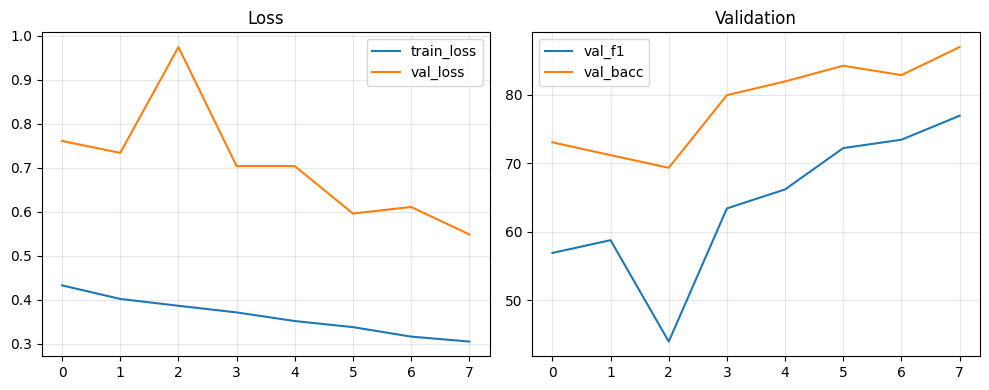

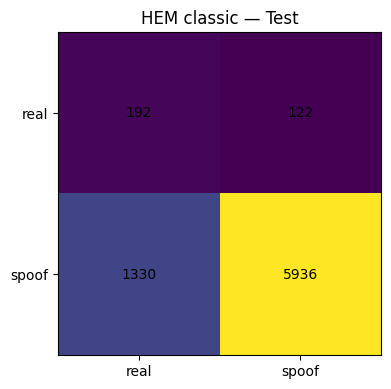

In [ ]:
# CELL 9 — Final test on best model
best_model = load_base_model()
best_model.load_state_dict(torch.load(RUN_DIR / 'best_model.pth', map_location=DEVICE), strict=False)

test_metrics = evaluate(best_model, test_loader, criterion_eval)
save_json(test_metrics, RUN_DIR / 'test_metrics.json')
pd.DataFrame([{k: v for k, v in test_metrics.items() if k != 'cm'}]).to_csv(
    RUN_DIR / 'test_metrics.csv', index=False
)

print('Test metrics:')
for k, v in test_metrics.items():
    if k == 'cm':
        continue
    if isinstance(v, float):
        print(f'{k:12s}: {v:.4f}')
    else:
        print(f'{k:12s}: {v}')

plot_history(history, RUN_DIR)
plot_cm(test_metrics['cm'], 'HEM classic — Test', RUN_DIR / 'confusion_matrix.png')